In [1]:
!pip install pdfplumber python-docx nltk scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 46.4 MB/s eta 0:00:00


In [2]:
import pdfplumber
import docx
import nltk
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

**UPLOAD SAMPLE RESUME**

In [4]:
from google.colab import files

uploaded = files.upload()

Saving NESETHA J C - DA.pdf to NESETHA J C - DA.pdf


**EXTRACT TEXT FROM PDF RESUMES**

In [6]:
def extract_text_from_pdf(pdf_file):
    text = ""

    with pdfplumber.open(pdf_file) as pdf:
        for page in pdf.pages:
            text += page.extract_text()

    return text

**EXTRACT TEXT FROM DOCX RESUMES**

In [7]:
def extract_text_from_docx(docx_file):
    doc = docx.Document(docx_file)

    text = ""

    for para in doc.paragraphs:
        text += para.text + "\n"

    return text

**READ AND PROCESS UPLOADED RESUME FILE**

In [8]:
file_name = list(uploaded.keys())[0]

if file_name.endswith('.pdf'):
    resume_text = extract_text_from_pdf(file_name)

elif file_name.endswith('.docx'):
    resume_text = extract_text_from_docx(file_name)

else:
    resume_text = "Unsupported file format"

print(resume_text)

NESETHA J C
nesethha08@gmail.com | +91 6384312346 | Chennai, India | https://github.com/Nesetha/BA_projects
OBJECTIVE
Analytical and detail-oriented Business Analytics student with hands-on experience in Python, SQL, Excel, Tableau,
and data reporting. Skilled in exploratory data analysis, report validation, dashboard creation, and automation
workflows. Strong ability to transform raw data into actionable insights and support data-driven decisions. Quick
learner with strong critical thinking and process improvement mindset.
EDUCATION
VIT Chennai
Integrated M.Tech in Computer Science with Business Analytics
Expected Graduation: 2028
SKILLS
• Programming & Analytics: Python | SQL | R (Basic) | Excel
• Excel: Pivot Tables | VLOOKUP | Data Cleaning
• Visualization & BI: Tableau | Power BI
• Reporting & Automation: KPI Reporting | Report Validation | Data Automation | Process Improvement
• Data Analytics: Data Cleaning | Exploratory Data Analysis | Data Profiling | KPI Analysis | Dashboard


In [30]:
from google.colab import files

uploaded = files.upload()

Saving skills_database.csv to skills_database.csv


In [31]:
import pandas as pd

skills_df = pd.read_csv("skills_database.csv")

skills_db = skills_df["Skill"].str.lower().tolist()

print(skills_db[:20])

['python', 'java', 'c', 'c++', 'javascript', 'typescript', 'r', 'go', 'swift', 'kotlin', 'php', 'ruby', 'scala', 'machine learning', 'deep learning', 'artificial intelligence', 'nlp', 'computer vision', 'data analysis', 'data visualization']


**EXTRACT SKILLS**

In [32]:
def extract_skills(resume_text, skills_db):

    resume_text = resume_text.lower()

    found_skills = set()

    for skill in skills_db:
        if skill in resume_text:
            found_skills.add(skill)

    return list(found_skills)

In [33]:
extracted_skills = extract_skills(resume_text, skills_db)

print("Extracted Skills:")
print(extracted_skills)

Extracted Skills:
['pandas', 'machine learning', 'scala', 'c', 'r', 'sql', 'excel', 'communication', 'python', 'critical thinking', 'power bi', 'data visualization', 'tableau', 'git', 'data analysis']


**PREDEFINED JOB DESCRIPTION**

In [34]:
job_description = """
We are looking for an AI/ML Intern with knowledge in Python,
Machine Learning, SQL, Data Analysis, NLP, Pandas,
Scikit-learn, and Data Visualization.

Candidates should have experience in predictive modeling
and AI-based projects.
"""

In [35]:
text_data = [resume_text, job_description]

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(text_data)

**COSINE SIMILARITY**

In [36]:
similarity_score = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])

match_percentage = round(similarity_score[0][0] * 100, 2)

print("Resume Match Score:", match_percentage, "%")

Resume Match Score: 37.18 %


**EXTRACTING REQUIRED SKILLS**

In [37]:
job_skills = extract_skills(job_description.lower(), skills_db)

print("Job Required Skills:")
print(job_skills)

Job Required Skills:
['nlp', 'pandas', 'machine learning', 'c', 'r', 'sql', 'scikit-learn', 'python', 'predictive modeling', 'data visualization', 'data analysis']


**MATCHED SKILLS**

In [38]:
matched_skills = []

for skill in extracted_skills:
    if skill in job_skills:
        matched_skills.append(skill)

print("Matched Skills:")
print(matched_skills)

Matched Skills:
['pandas', 'machine learning', 'c', 'r', 'sql', 'python', 'data visualization', 'data analysis']


**MISSING SKILLS**

In [39]:
missing_skills = []

for skill in job_skills:
    if skill not in extracted_skills:
        missing_skills.append(skill)

print("Missing Skills:")
print(missing_skills)

Missing Skills:
['nlp', 'scikit-learn', 'predictive modeling']


In [19]:
from google.colab import files

uploaded_files = files.upload()

Saving NESETHA J C - DA.pdf to NESETHA J C - DA (1).pdf
Saving Resume - BA.pdf to Resume - BA.pdf


**EXTRACT CANDIDATE NAME**

In [45]:
def extract_name(resume_text):

    lines = resume_text.strip().split('\n')

    for line in lines:

        line = line.strip()

        # Ignore empty lines
        if line:

            # Return first meaningful line
            return line

    return "Unknown Candidate"

**PROCESS MULTIPLE RESUMES AND RANK CANDIDATES**

In [55]:
results = []

for file_name in uploaded_files.keys():

    # Extract text from resumes
    if file_name.endswith('.pdf'):
        text = extract_text_from_pdf(file_name)

    elif file_name.endswith('.docx'):
        text = extract_text_from_docx(file_name)

    else:
        continue

    # Extract candidate name
    candidate_name = extract_name(text)

    # Convert text to lowercase
    text = text.lower()

    # TF-IDF Matching
    text_data = [text, job_description]

    vectorizer = TfidfVectorizer()

    tfidf_matrix = vectorizer.fit_transform(text_data)

    similarity_score = cosine_similarity(
        tfidf_matrix[0:1],
        tfidf_matrix[1:2]
    )

    match_percentage = round(similarity_score[0][0] * 100, 2)

    # Extract skills
    skills = extract_skills(text, skills_db)

    # Store results
    results.append({
        "Candidate": candidate_name,
        "Match Score": match_percentage,
        "Skills": ", ".join(skills)
    })

In [57]:
results_df = pd.DataFrame(results)
results_df

#SORT
ranked_df = results_df.sort_values(
    by="Match Score",
    ascending=False
)
ranked_df

,Candidate,Match Score,Skills
0,NESETHA J C,37.18,"pandas, machine learning, scala, c, r, sql, ex..."
1,NESETHA J C,25.17,"c, excel, sql, r, communication, python, risk ..."


**RANKING VISUALIZATION**

In [51]:
import matplotlib.pyplot as plt

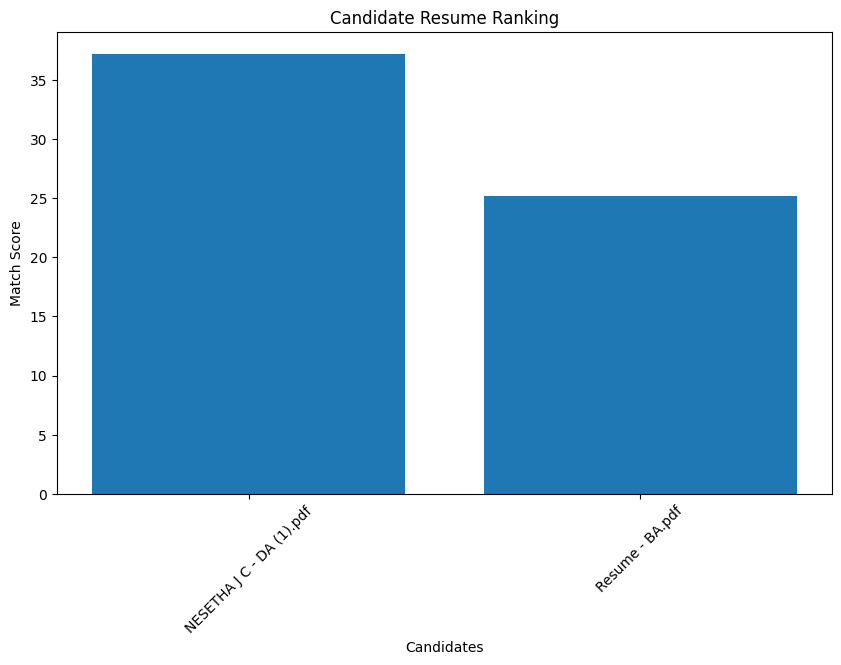

In [52]:
plt.figure(figsize=(10, 6))

plt.bar(
    ranked_df["Candidate"],
    ranked_df["Match Score"]
)

plt.xlabel("Candidates")
plt.ylabel("Match Score")
plt.title("Candidate Resume Ranking")

plt.xticks(rotation=45)

plt.show()

**RANKING THE CANDIDATES**

In [58]:
ranked_df
ranked_df = ranked_df.reset_index(drop=True)
ranked_df.index = ranked_df.index + 1
ranked_df.index.name = "Rank"
ranked_df

,Candidate,Match Score,Skills
Rank,,,
1,NESETHA J C,37.18,"pandas, machine learning, scala, c, r, sql, ex..."
2,NESETHA J C,25.17,"c, excel, sql, r, communication, python, risk ..."


**TOP CANDIDATE**

In [59]:
top_candidate = ranked_df.iloc[0]

print("Top Candidate:")
print(top_candidate)

Top Candidate:
Candidate                                            NESETHA J C
Match Score                                                37.18
Skills         pandas, machine learning, scala, c, r, sql, ex...
Name: 1, dtype: object
